<a href="https://colab.research.google.com/github/shifanamattil/churn-prediction/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Features dropped due to high VIF (>10):
['MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'PhoneService_Yes']

================ MODEL PERFORMANCE ================

Best Parameters Found:
{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

Accuracy:  0.7055
Precision: 0.4687
Recall:    0.8209
F1 Score:  0.5967
MCC:       0.4290
ROC-AUC:   0.8198

================ ADDITIONAL METRICS ================

Sensitivity (TPR): 82.09%
Specificity (TNR): 66.38%


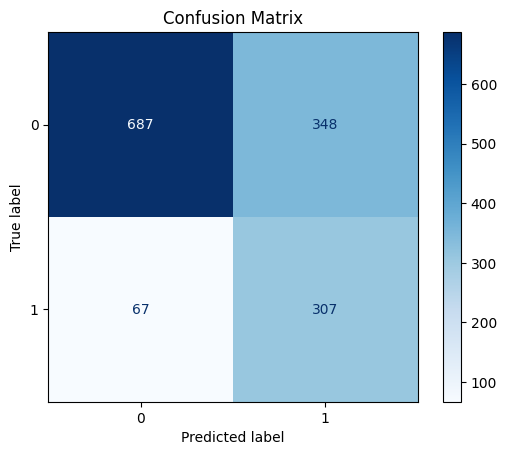

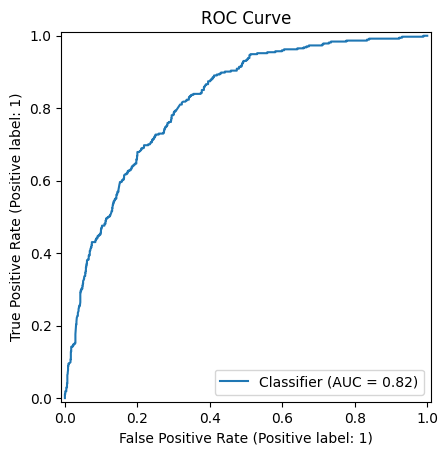


Features Increasing Churn:
                           Feature  Coefficient
11            PaperlessBilling_Yes     0.331670
13  PaymentMethod_Electronic check     0.285486
4                MultipleLines_Yes     0.233549
7             DeviceProtection_Yes     0.111472
0                    SeniorCitizen     0.105514

Features Decreasing Churn:
               Feature  Coefficient
5   OnlineSecurity_Yes    -0.129232
3       Dependents_Yes    -0.171801
9    Contract_One year    -0.371254
1               tenure    -0.592540
10   Contract_Two year    -0.706163


In [ ]:
# =========================================================
# 1. Import Libraries
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE


# =========================================================
# 2. Load Datasets
# =========================================================
customer_df = pd.read_csv("customer_data (1).csv")
internet_df = pd.read_csv("internet_data (1).csv")
churn_df = pd.read_csv("churn_data (1).csv")


# =========================================================
# 3. Merge Datasets
# =========================================================
df = customer_df.merge(internet_df, on="customerID", how="inner")
df = df.merge(churn_df, on="customerID", how="inner")

df.drop(columns=["customerID"], inplace=True)


# =========================================================
# 4. Target Variable
# =========================================================
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


# =========================================================
# 5. Handle TotalCharges
# =========================================================
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)


# =========================================================
# 6. Encode Categorical Variables
# =========================================================
df = pd.get_dummies(df, drop_first=True)


# =========================================================
# 7. Split Features and Target
# =========================================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

feature_names = X.columns


# =========================================================
# 8. Train Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 9. Feature Scaling
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)


# =========================================================
# 10. Multicollinearity Check (VIF)
# =========================================================
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled.values, i)
    for i in range(X_train_scaled.shape[1])
]

features_to_drop = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()

print("\nFeatures dropped due to high VIF (>10):")
print(features_to_drop)

X_train_vif = X_train_scaled.drop(columns=features_to_drop)
X_test_vif = X_test_scaled.drop(columns=features_to_drop)


# =========================================================
# 11. Handle Class Imbalance (SMOTE)
# =========================================================
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_vif,
    y_train
)





# =========================================================
# 13. Hyperparameter Tuning (GridSearchCV)
# =========================================================
log_model = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_rfe, y_train_smote)

best_model = grid.best_estimator_


# =========================================================
# 14. Predictions
# =========================================================
y_pred = best_model.predict(X_test_rfe)
y_prob = best_model.predict_proba(X_test_rfe)[:,1]


# =========================================================
# 15. Evaluation Metrics
# =========================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n================ MODEL PERFORMANCE ================\n")

print("Best Parameters Found:")
print(grid.best_params_)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


# =========================================================
# 16. Sensitivity & Specificity
# =========================================================
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("\n================ ADDITIONAL METRICS ================\n")

print(f"Sensitivity (TPR): {sensitivity*100:.2f}%")
print(f"Specificity (TNR): {specificity*100:.2f}%")


# =========================================================
# 17. Confusion Matrix
# =========================================================
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()


# =========================================================
# 18. ROC Curve
# =========================================================
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()


# =========================================================
# 19. Feature Importance (Logistic Coefficients)
# =========================================================
coef = best_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coef
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeatures Increasing Churn:")
print(coef_df.head())

print("\nFeatures Decreasing Churn:")
print(coef_df.tail())